In [1]:
import pandas as pd

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
data = pd.read_csv(url, header=None)

In [3]:
X = data.iloc[:, :4].values
true_labels = data[4].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}).values

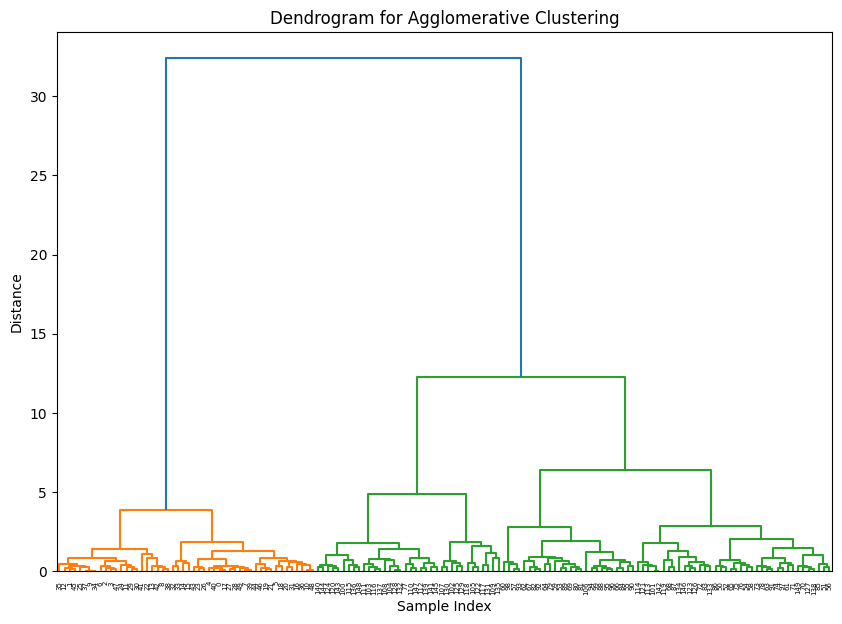

In [4]:
# Show me the whole family tree
from scipy.cluster.hierarchy import linkage, dendrogram
Z = linkage(X, method='ward')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [5]:
# Just tell me who belongs to which of the 3 families
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X)

In [6]:
# Reduce to 2D for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

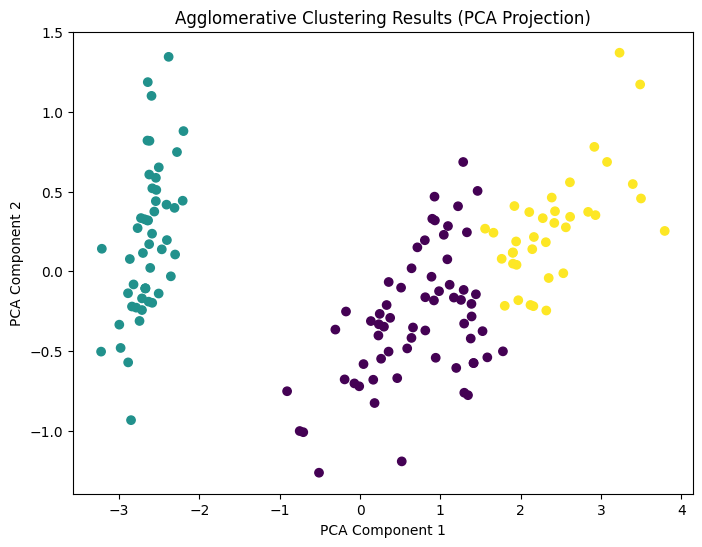

In [7]:
# Plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
plt.title('Agglomerative Clustering Results (PCA Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [8]:
from sklearn.metrics import silhouette_score, adjusted_rand_score
sil_score = silhouette_score(X, labels)
ari = adjusted_rand_score(true_labels, labels)

In [9]:
print(f'Silhouette Score (internal accuracy metric): {sil_score:.4f}')
print(f'Adjusted Rand Index (with true labels): {ari:.4f}')

Silhouette Score (internal accuracy metric): 0.5541
Adjusted Rand Index (with true labels): 0.7312


In [10]:
# Divisive is computationally complex and not good fit for large sclae dataset